In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
equip_rep_clean=pd.read_csv("../DATA/equip_rep_clean.csv")

### 2.1 Calculo de Estadısticos Generales

In [5]:
columns=['possessionPct',
       'foulsCommitted', 'yellowCards', 'redCards', 'offsides', 'wonCorners',
       'saves', 'totalShots', 'shotsOnTarget', 'shotPct', 'penaltyKickGoals',
       'penaltyKickShots', 'accuratePasses', 'totalPasses', 'passPct',
       'accurateCrosses', 'totalCrosses', 'crossPct', 'totalLongBalls',
       'accurateLongBalls', 'longballPct', 'blockedShots', 'effectiveTackles',
       'totalTackles', 'tacklePct', 'interceptions', 'effectiveClearance',
       'totalClearance']

In [12]:
media = equip_rep_clean[columns].mean()
print(f"\nMedia:\n{media}")
varianza = equip_rep_clean[columns].var()
print(f"Varianza:{varianza}")
Desviacion_Estandar = equip_rep_clean[columns].std()
print(f"Desviacion Estandar:{Desviacion_Estandar}")
mediana = equip_rep_clean[columns].median()
print(f"Mediana:{mediana}")
moda = equip_rep_clean[columns].mode()
print(f"Moda:{moda}")
q1 = equip_rep_clean[columns].quantile(0.25)
q2 = equip_rep_clean[columns].quantile(0.50)
q3 = equip_rep_clean[columns].quantile(0.75)
print(f"Q1:{q1}")
print(f"Q2:{q2}")
print(f"Q3:{q3}")


Media:
possessionPct          60.229874
foulsCommitted         10.197248
yellowCards             1.605505
redCards                0.082569
offsides                1.628440
wonCorners              6.122706
saves                   2.393349
totalShots             16.099771
shotsOnTarget           6.334862
shotPct                 0.401261
penaltyKickGoals        0.165138
penaltyKickShots        0.208716
accuratePasses        514.739679
totalPasses           581.776376
passPct                 0.877752
accurateCrosses         4.044725
totalCrosses           16.961009
crossPct                0.239564
totalLongBalls         42.530963
accurateLongBalls      23.158830
longballPct             0.549312
blockedShots            4.244266
effectiveTackles        9.540138
totalTackles           15.254587
tacklePct               0.618406
interceptions           7.405963
effectiveClearance     16.611239
totalClearance         16.611239
dtype: float64
Varianza:possessionPct           120.032990
foulsComm

In [15]:
equip_rep_est = equip_rep_clean[columns].describe(include='number', percentiles=[.25, .5, .75]).T
equip_rep_est['variance'] = equip_rep_clean[columns].var()
equip_rep_est['std'] = equip_rep_clean[columns].std()
equip_rep_est['median'] = equip_rep_clean[columns].median()
equip_rep_est['mode'] = equip_rep_clean[columns].apply(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
)

equip_rep_est

,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,872.0,60.229874,10.955957,22.8,53.075,61.05,68.40,85.2,120.032990,61.05,58.4
foulsCommitted,872.0,10.197248,3.522288,1.0,8.000,10.00,12.00,23.0,12.406514,10.00,9.0
yellowCards,872.0,1.605505,1.326362,0.0,1.000,1.00,2.00,8.0,1.759235,1.00,1.0
redCards,872.0,0.082569,0.303169,0.0,0.000,0.00,0.00,3.0,0.091912,0.00,0.0
offsides,872.0,1.628440,1.567324,0.0,0.000,1.00,2.00,12.0,2.456504,1.00,1.0
wonCorners,872.0,6.122706,3.427764,0.0,4.000,6.00,8.00,26.0,11.749564,6.00,4.0
saves,872.0,2.393349,1.863937,0.0,1.000,2.00,3.00,11.0,3.474261,2.00,1.0
totalShots,872.0,16.099771,6.535457,0.0,12.000,16.00,20.00,80.0,42.712193,16.00,12.0
shotsOnTarget,872.0,6.334862,3.228074,0.0,4.000,6.00,8.00,38.0,10.420459,6.00,5.0
shotPct,872.0,0.401261,0.149736,0.0,0.300,0.40,0.50,1.0,0.022421,0.40,0.4


### 2.2 Matriz de Correlacion

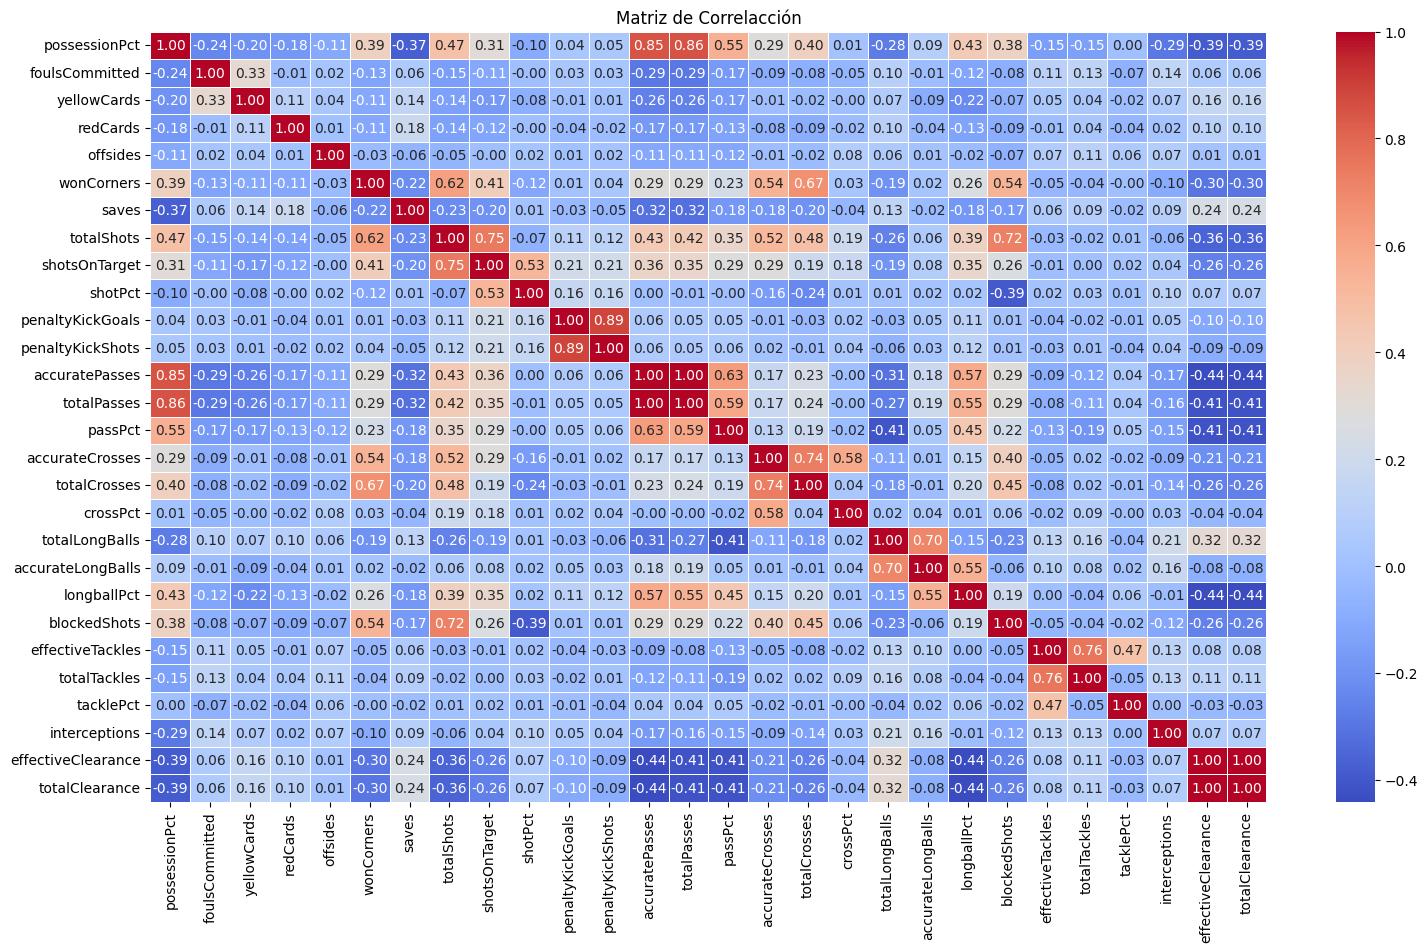

In [19]:
matriz_correlacion = equip_rep_clean[columns].corr()
plt.figure(figsize=(18,10))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, cbar=True)
plt.title("Matriz de Correlacción")
plt.show()

In [20]:
from IPython.display import display, HTML

teams = ['esp.barcelona', 'esp.real_madrid', 'ger.dortmund', 'ger.bayern_munich',
         'fra.psg', 'eng.arsenal', 'eng.chelsea', 'eng.liverpool',
         'eng.man_city', 'esp.atletico_madrid']

for team in teams:
    team_data = equip_rep_clean.query(f"slug == '{team}'")[columns]

    equip_rep_est = team_data.describe(include='number', percentiles=[.25, .5, .75]).T


    equip_rep_est['variance'] = team_data.var()
    equip_rep_est['median'] = team_data.median()
    equip_rep_est['mode'] = team_data.apply(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    )


    display(HTML(f"<h2>Statistics for: {team}</h2>"))
    display(equip_rep_est)
    display(HTML("<hr>")) 

,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,86.0,65.794186,9.719082,39.8,59.675,68.100,72.450,82.0,94.460554,68.100,59.5
foulsCommitted,86.0,10.011628,3.805551,3.0,7.250,10.000,12.000,23.0,14.482216,10.000,10.0
yellowCards,86.0,1.558140,1.435718,0.0,0.000,1.000,2.000,5.0,2.061286,1.000,0.0
redCards,86.0,0.104651,0.307899,0.0,0.000,0.000,0.000,1.0,0.094802,0.000,0.0
offsides,86.0,1.616279,1.587959,0.0,0.000,1.000,2.000,8.0,2.521614,1.000,1.0
wonCorners,86.0,6.186047,2.879998,0.0,4.000,6.000,8.000,14.0,8.294391,6.000,4.0
saves,86.0,2.255814,1.965503,0.0,1.000,2.000,3.000,9.0,3.863201,2.000,1.0
totalShots,86.0,17.372093,5.770200,4.0,13.000,17.500,21.000,40.0,33.295212,17.500,19.0
shotsOnTarget,86.0,6.813953,2.641353,0.0,5.000,7.000,9.000,12.0,6.976744,7.000,9.0
shotPct,86.0,0.397674,0.116797,0.0,0.300,0.400,0.500,0.6,0.013642,0.400,0.3


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,94.0,57.907447,10.067420,31.6,51.55,58.70,64.875,78.0,101.352955,58.70,62.0
foulsCommitted,94.0,9.787234,3.195670,1.0,7.00,10.00,12.000,18.0,10.212308,10.00,9.0
yellowCards,94.0,1.723404,1.439865,0.0,1.00,1.00,3.000,5.0,2.073210,1.00,1.0
redCards,94.0,0.170213,0.521336,0.0,0.00,0.00,0.000,3.0,0.271791,0.00,0.0
offsides,94.0,1.723404,1.874585,0.0,0.00,1.00,2.750,12.0,3.514070,1.00,0.0
wonCorners,94.0,6.489362,3.564293,2.0,4.00,6.00,8.000,26.0,12.704187,6.00,5.0
saves,94.0,2.936170,2.119081,0.0,1.00,3.00,4.000,10.0,4.490506,3.00,1.0
totalShots,94.0,17.265957,6.469408,6.0,12.00,16.00,21.750,39.0,41.853237,16.00,16.0
shotsOnTarget,94.0,6.840426,3.357877,1.0,5.00,6.50,9.000,21.0,11.275337,6.50,7.0
shotPct,94.0,0.396809,0.116814,0.1,0.30,0.40,0.500,0.7,0.013646,0.40,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,81.0,56.728395,11.113969,32.7,48.4,55.2,65.9,85.2,123.520309,55.2,54.5
foulsCommitted,81.0,10.740741,3.538283,4.0,8.0,11.0,13.0,18.0,12.519444,11.0,11.0
yellowCards,81.0,1.666667,1.244990,0.0,1.0,1.0,2.0,5.0,1.550000,1.0,1.0
redCards,81.0,0.086420,0.282734,0.0,0.0,0.0,0.0,1.0,0.079938,0.0,0.0
offsides,81.0,1.456790,1.351382,0.0,0.0,1.0,2.0,6.0,1.826235,1.0,0.0
wonCorners,81.0,5.395062,2.969339,0.0,3.0,5.0,7.0,17.0,8.816975,5.0,3.0
saves,81.0,2.765432,2.014147,0.0,1.0,2.0,4.0,9.0,4.056790,2.0,2.0
totalShots,81.0,13.395062,5.571533,0.0,9.0,13.0,17.0,28.0,31.041975,13.0,8.0
shotsOnTarget,81.0,5.086420,2.656113,0.0,3.0,5.0,7.0,13.0,7.054938,5.0,4.0
shotPct,81.0,0.395062,0.180901,0.0,0.3,0.4,0.5,0.9,0.032725,0.4,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,86.0,66.105233,9.430701,29.0,60.275,66.975,72.40,83.1,88.938119,66.975,69.9
foulsCommitted,86.0,9.639535,3.184199,2.0,8.000,9.000,12.00,19.0,10.139124,9.000,9.0
yellowCards,86.0,1.488372,1.271814,0.0,0.250,1.000,2.00,5.0,1.617510,1.000,1.0
redCards,86.0,0.046512,0.211825,0.0,0.000,0.000,0.00,1.0,0.044870,0.000,0.0
offsides,86.0,1.813953,1.545480,0.0,1.000,1.000,3.00,6.0,2.388509,1.000,1.0
wonCorners,86.0,6.616279,3.748470,0.0,4.000,6.000,9.00,25.0,14.051026,6.000,4.0
saves,86.0,1.720930,1.500205,0.0,1.000,1.000,3.00,8.0,2.250616,1.000,1.0
totalShots,86.0,19.453488,9.214639,1.0,14.000,19.000,23.00,80.0,84.909576,19.000,19.0
shotsOnTarget,86.0,8.011628,4.936048,0.0,5.000,7.000,10.00,38.0,24.364569,7.000,10.0
shotPct,86.0,0.412791,0.143729,0.0,0.300,0.400,0.50,1.0,0.020658,0.400,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,89.0,67.534831,8.221108,42.6,63.6,68.1,73.2,84.1,67.586614,68.1,65.2
foulsCommitted,89.0,9.337079,3.078311,3.0,7.0,9.0,11.0,17.0,9.475996,9.0,9.0
yellowCards,89.0,1.112360,0.958671,0.0,0.0,1.0,2.0,4.0,0.919050,1.0,1.0
redCards,89.0,0.067416,0.293790,0.0,0.0,0.0,0.0,2.0,0.086313,0.0,0.0
offsides,89.0,1.528090,1.596088,0.0,0.0,1.0,2.0,8.0,2.547497,1.0,0.0
wonCorners,89.0,6.438202,3.496606,0.0,4.0,6.0,8.0,17.0,12.226251,6.0,5.0
saves,89.0,2.146067,1.488979,0.0,1.0,2.0,3.0,6.0,2.217058,2.0,2.0
totalShots,89.0,18.213483,5.767211,8.0,14.0,18.0,22.0,32.0,33.260725,18.0,18.0
shotsOnTarget,89.0,7.471910,2.540982,2.0,6.0,8.0,9.0,13.0,6.456588,8.0,8.0
shotPct,89.0,0.425843,0.141042,0.1,0.3,0.4,0.5,0.8,0.019893,0.4,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,86.0,56.861628,10.628200,22.8,50.70,57.15,64.575,76.8,112.958628,57.15,50.3
foulsCommitted,86.0,10.523256,3.747083,2.0,8.00,10.00,13.000,21.0,14.040629,10.00,10.0
yellowCards,86.0,1.569767,1.251265,0.0,1.00,1.00,2.000,6.0,1.565663,1.00,1.0
redCards,86.0,0.069767,0.256249,0.0,0.00,0.00,0.000,1.0,0.065663,0.00,0.0
offsides,86.0,1.883721,1.597193,0.0,1.00,2.00,3.000,7.0,2.551026,2.00,1.0
wonCorners,86.0,6.325581,3.774346,1.0,3.00,5.00,8.750,17.0,14.245691,5.00,3.0
saves,86.0,2.197674,1.839564,0.0,1.00,2.00,3.000,9.0,3.383995,2.00,2.0
totalShots,86.0,14.465116,5.275242,5.0,11.00,14.00,17.000,35.0,27.828181,14.00,12.0
shotsOnTarget,86.0,5.511628,2.547175,1.0,4.00,5.00,7.000,16.0,6.488098,5.00,5.0
shotPct,86.0,0.398837,0.173879,0.1,0.30,0.40,0.500,0.9,0.030234,0.40,0.3


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,91.0,58.979121,9.610983,33.5,53.4,59.1,65.65,81.3,92.371004,59.1,59.1
foulsCommitted,91.0,11.527473,3.452344,3.0,9.0,12.0,14.00,21.0,11.918681,12.0,12.0
yellowCards,91.0,2.000000,1.505545,0.0,1.0,2.0,3.00,8.0,2.266667,2.0,2.0
redCards,91.0,0.098901,0.300183,0.0,0.0,0.0,0.00,1.0,0.090110,0.0,0.0
offsides,91.0,1.582418,1.506032,0.0,0.5,1.0,2.50,6.0,2.268132,1.0,1.0
wonCorners,91.0,5.769231,2.996579,0.0,4.0,5.0,8.00,15.0,8.979487,5.0,4.0
saves,91.0,2.692308,1.936161,0.0,1.0,2.0,3.00,11.0,3.748718,2.0,2.0
totalShots,91.0,15.472527,5.924226,0.0,11.0,15.0,19.00,34.0,35.096459,15.0,17.0
shotsOnTarget,91.0,6.021978,3.130417,0.0,3.5,6.0,8.00,18.0,9.799512,6.0,7.0
shotPct,91.0,0.384615,0.143700,0.0,0.3,0.4,0.50,0.7,0.020650,0.4,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,86.0,58.366279,9.765433,29.6,51.85,59.25,63.875,81.0,95.363673,59.25,46.8
foulsCommitted,86.0,10.837209,3.356681,4.0,8.00,10.00,13.750,20.0,11.267305,10.00,10.0
yellowCards,86.0,1.569767,1.193519,0.0,1.00,2.00,2.000,5.0,1.424487,2.00,2.0
redCards,86.0,0.058140,0.235380,0.0,0.00,0.00,0.000,1.0,0.055404,0.00,0.0
offsides,86.0,1.627907,1.630925,0.0,0.00,1.00,2.000,8.0,2.659918,1.00,1.0
wonCorners,86.0,5.779070,3.569153,0.0,3.00,5.00,8.000,15.0,12.738851,5.00,2.0
saves,86.0,2.697674,2.092394,0.0,1.00,2.00,4.000,9.0,4.378112,2.00,1.0
totalShots,86.0,15.813953,6.474405,0.0,11.00,16.00,19.000,37.0,41.917921,16.00,9.0
shotsOnTarget,86.0,5.802326,2.913739,0.0,4.00,5.00,7.000,14.0,8.489877,5.00,4.0
shotPct,86.0,0.387209,0.159260,0.0,0.30,0.40,0.500,0.8,0.025364,0.40,0.3


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,87.0,61.691954,10.200561,33.2,55.25,63.5,69.00,79.9,104.051446,63.5,51.8
foulsCommitted,87.0,8.436782,3.536195,2.0,6.00,8.0,10.00,19.0,12.504678,8.0,7.0
yellowCards,87.0,1.471264,1.310415,0.0,0.00,1.0,2.00,5.0,1.717188,1.0,0.0
redCards,87.0,0.034483,0.183523,0.0,0.00,0.0,0.00,1.0,0.033681,0.0,0.0
offsides,87.0,1.091954,1.106347,0.0,0.00,1.0,2.00,5.0,1.224004,1.0,1.0
wonCorners,87.0,6.689655,3.879914,1.0,4.00,6.0,9.00,20.0,15.053729,6.0,6.0
saves,87.0,2.091954,1.411186,0.0,1.00,2.0,3.00,6.0,1.991446,2.0,2.0
totalShots,87.0,16.367816,5.640623,5.0,12.00,16.0,20.00,33.0,31.816627,16.0,12.0
shotsOnTarget,87.0,6.264368,2.576548,1.0,4.50,6.0,8.00,15.0,6.638599,6.0,6.0
shotPct,87.0,0.397701,0.135524,0.1,0.30,0.4,0.50,0.7,0.018367,0.4,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,86.0,52.143023,10.642849,25.6,45.625,52.75,58.975,81.5,113.270245,52.75,58.9
foulsCommitted,86.0,11.174419,3.319078,4.0,9.000,11.00,13.000,20.0,11.016279,11.00,11.0
yellowCards,86.0,1.883721,1.409369,0.0,1.000,2.00,3.000,5.0,1.986320,2.00,1.0
redCards,86.0,0.081395,0.275045,0.0,0.000,0.00,0.000,1.0,0.075650,0.00,0.0
offsides,86.0,1.953488,1.629919,0.0,1.000,2.00,3.000,8.0,2.656635,2.00,1.0
wonCorners,86.0,5.465116,3.066700,0.0,3.000,5.00,7.000,21.0,9.404651,5.00,3.0
saves,86.0,2.395349,1.842499,0.0,1.000,2.00,3.000,8.0,3.394802,2.00,1.0
totalShots,86.0,12.872093,5.562049,4.0,9.000,12.00,15.000,28.0,30.936389,12.00,9.0
shotsOnTarget,86.0,5.383721,3.083804,0.0,3.000,5.00,7.750,13.0,9.509850,5.00,2.0
shotPct,86.0,0.416279,0.177473,0.0,0.300,0.40,0.500,0.8,0.031497,0.40,0.3


In [6]:
import os
from IPython.display import display, HTML
import pandas as pd
import numpy as np

os.makedirs('../tables', exist_ok=True)

teams = ['esp.barcelona', 'esp.real_madrid', 'ger.dortmund', 'ger.bayern_munich',
         'fra.psg', 'eng.arsenal', 'eng.chelsea', 'eng.liverpool',
         'eng.man_city', 'esp.atletico_madrid']

team_names = {
    'esp.barcelona': 'FC Barcelona',
    'esp.real_madrid': 'Real Madrid',
    'ger.dortmund': 'Borussia Dortmund',
    'ger.bayern_munich': 'Bayern Munich',
    'fra.psg': 'Paris Saint-Germain',
    'eng.arsenal': 'Arsenal FC',
    'eng.chelsea': 'Chelsea FC',
    'eng.liverpool': 'Liverpool FC',
    'eng.man_city': 'Manchester City',
    'esp.atletico_madrid': 'Atlético Madrid'
}

for team in teams:
    team_data = equip_rep_clean.query(f"slug == '{team}'")[columns]

    equip_rep_est = team_data.describe(include='number', percentiles=[.25, .5, .75]).T.rename(columns={
        '25%': 'Q1',
        '50%': 'Q2',
        '75%': 'Q3'})
    equip_rep_est['variance'] = team_data.var()
    equip_rep_est['median'] = team_data.median()
    equip_rep_est['mode'] = team_data.apply(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    )
    
    equip_rep_est = equip_rep_est[["mean","std", "Q1","Q2","Q3","variance","mode"]].round(2)
    filename = team.replace('.', '_')
    nice_name = team_names.get(team, team)
    
    filepath = f'../tables/tabla_{filename}.tex'
    
    # Generate complete table with wrapper
    with open(filepath, 'w', encoding='utf-8') as f:
        # Start table environment
        f.write('\\begin{table}[H]\n')
        f.write('\\centering\n')
        f.write(f'\\caption{{Estadísticas Descriptivas - {nice_name}}}\n')
        f.write(f'\\label{{tab:{filename}}}\n')
        f.write('\\small\n')
        
        # Column format
        num_cols = len(equip_rep_est.columns)
        col_format = 'l' + 'r' * num_cols
        
        # Start tabular
        f.write(f'\\begin{{tabular}}{{{col_format}}}\n')
        f.write('\\hline\n')
        
        # Header
        headers = ['Variable'] + [str(col) for col in equip_rep_est.columns]
        f.write(' & '.join(headers) + ' \\\\\n')
        f.write('\\hline\n')
        
        # Data rows
        for idx, row in equip_rep_est.iterrows():
            row_data = [str(idx)]
            for val in row:
                if pd.isna(val):
                    row_data.append('-')
                else:
                    row_data.append(f'{val:.2f}')
            f.write(' & '.join(row_data) + ' \\\\\n')
        
        f.write('\\hline\n')
        f.write('\\end{tabular}\n')
        f.write('\\end{table}\n')
    
    display(HTML(f"<h2>Statistics for: {nice_name}</h2>"))
    display(equip_rep_est)
    display(HTML("<hr>"))
    
    print(f"✓ Saved: {filepath}")

print(f"\n✅ All {len(teams)} complete tables saved")

,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,65.79,9.72,59.68,68.10,72.45,94.46,59.5
foulsCommitted,10.01,3.81,7.25,10.00,12.00,14.48,10.0
yellowCards,1.56,1.44,0.00,1.00,2.00,2.06,0.0
redCards,0.10,0.31,0.00,0.00,0.00,0.09,0.0
offsides,1.62,1.59,0.00,1.00,2.00,2.52,1.0
wonCorners,6.19,2.88,4.00,6.00,8.00,8.29,4.0
saves,2.26,1.97,1.00,2.00,3.00,3.86,1.0
totalShots,17.37,5.77,13.00,17.50,21.00,33.30,19.0
shotsOnTarget,6.81,2.64,5.00,7.00,9.00,6.98,9.0
shotPct,0.40,0.12,0.30,0.40,0.50,0.01,0.3


✓ Saved: ../tables/tabla_esp_barcelona.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,57.91,10.07,51.55,58.70,64.88,101.35,62.0
foulsCommitted,9.79,3.20,7.00,10.00,12.00,10.21,9.0
yellowCards,1.72,1.44,1.00,1.00,3.00,2.07,1.0
redCards,0.17,0.52,0.00,0.00,0.00,0.27,0.0
offsides,1.72,1.87,0.00,1.00,2.75,3.51,0.0
wonCorners,6.49,3.56,4.00,6.00,8.00,12.70,5.0
saves,2.94,2.12,1.00,3.00,4.00,4.49,1.0
totalShots,17.27,6.47,12.00,16.00,21.75,41.85,16.0
shotsOnTarget,6.84,3.36,5.00,6.50,9.00,11.28,7.0
shotPct,0.40,0.12,0.30,0.40,0.50,0.01,0.4


✓ Saved: ../tables/tabla_esp_real_madrid.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,56.73,11.11,48.4,55.2,65.9,123.52,54.5
foulsCommitted,10.74,3.54,8.0,11.0,13.0,12.52,11.0
yellowCards,1.67,1.24,1.0,1.0,2.0,1.55,1.0
redCards,0.09,0.28,0.0,0.0,0.0,0.08,0.0
offsides,1.46,1.35,0.0,1.0,2.0,1.83,0.0
wonCorners,5.40,2.97,3.0,5.0,7.0,8.82,3.0
saves,2.77,2.01,1.0,2.0,4.0,4.06,2.0
totalShots,13.40,5.57,9.0,13.0,17.0,31.04,8.0
shotsOnTarget,5.09,2.66,3.0,5.0,7.0,7.05,4.0
shotPct,0.40,0.18,0.3,0.4,0.5,0.03,0.4


...

✓ Saved: ../tables/tabla_eng_liverpool.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,61.69,10.20,55.25,63.5,69.00,104.05,51.8
foulsCommitted,8.44,3.54,6.00,8.0,10.00,12.50,7.0
yellowCards,1.47,1.31,0.00,1.0,2.00,1.72,0.0
redCards,0.03,0.18,0.00,0.0,0.00,0.03,0.0
offsides,1.09,1.11,0.00,1.0,2.00,1.22,1.0
wonCorners,6.69,3.88,4.00,6.0,9.00,15.05,6.0
saves,2.09,1.41,1.00,2.0,3.00,1.99,2.0
totalShots,16.37,5.64,12.00,16.0,20.00,31.82,12.0
shotsOnTarget,6.26,2.58,4.50,6.0,8.00,6.64,6.0
shotPct,0.40,0.14,0.30,0.4,0.50,0.02,0.4


✓ Saved: ../tables/tabla_eng_man_city.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,52.14,10.64,45.62,52.75,58.98,113.27,58.9
foulsCommitted,11.17,3.32,9.00,11.00,13.00,11.02,11.0
yellowCards,1.88,1.41,1.00,2.00,3.00,1.99,1.0
redCards,0.08,0.28,0.00,0.00,0.00,0.08,0.0
offsides,1.95,1.63,1.00,2.00,3.00,2.66,1.0
wonCorners,5.47,3.07,3.00,5.00,7.00,9.40,3.0
saves,2.40,1.84,1.00,2.00,3.00,3.39,1.0
totalShots,12.87,5.56,9.00,12.00,15.00,30.94,9.0
shotsOnTarget,5.38,3.08,3.00,5.00,7.75,9.51,2.0
shotPct,0.42,0.18,0.30,0.40,0.50,0.03,0.3


✓ Saved: ../tables/tabla_esp_atletico_madrid.tex

✅ All 10 complete tables saved


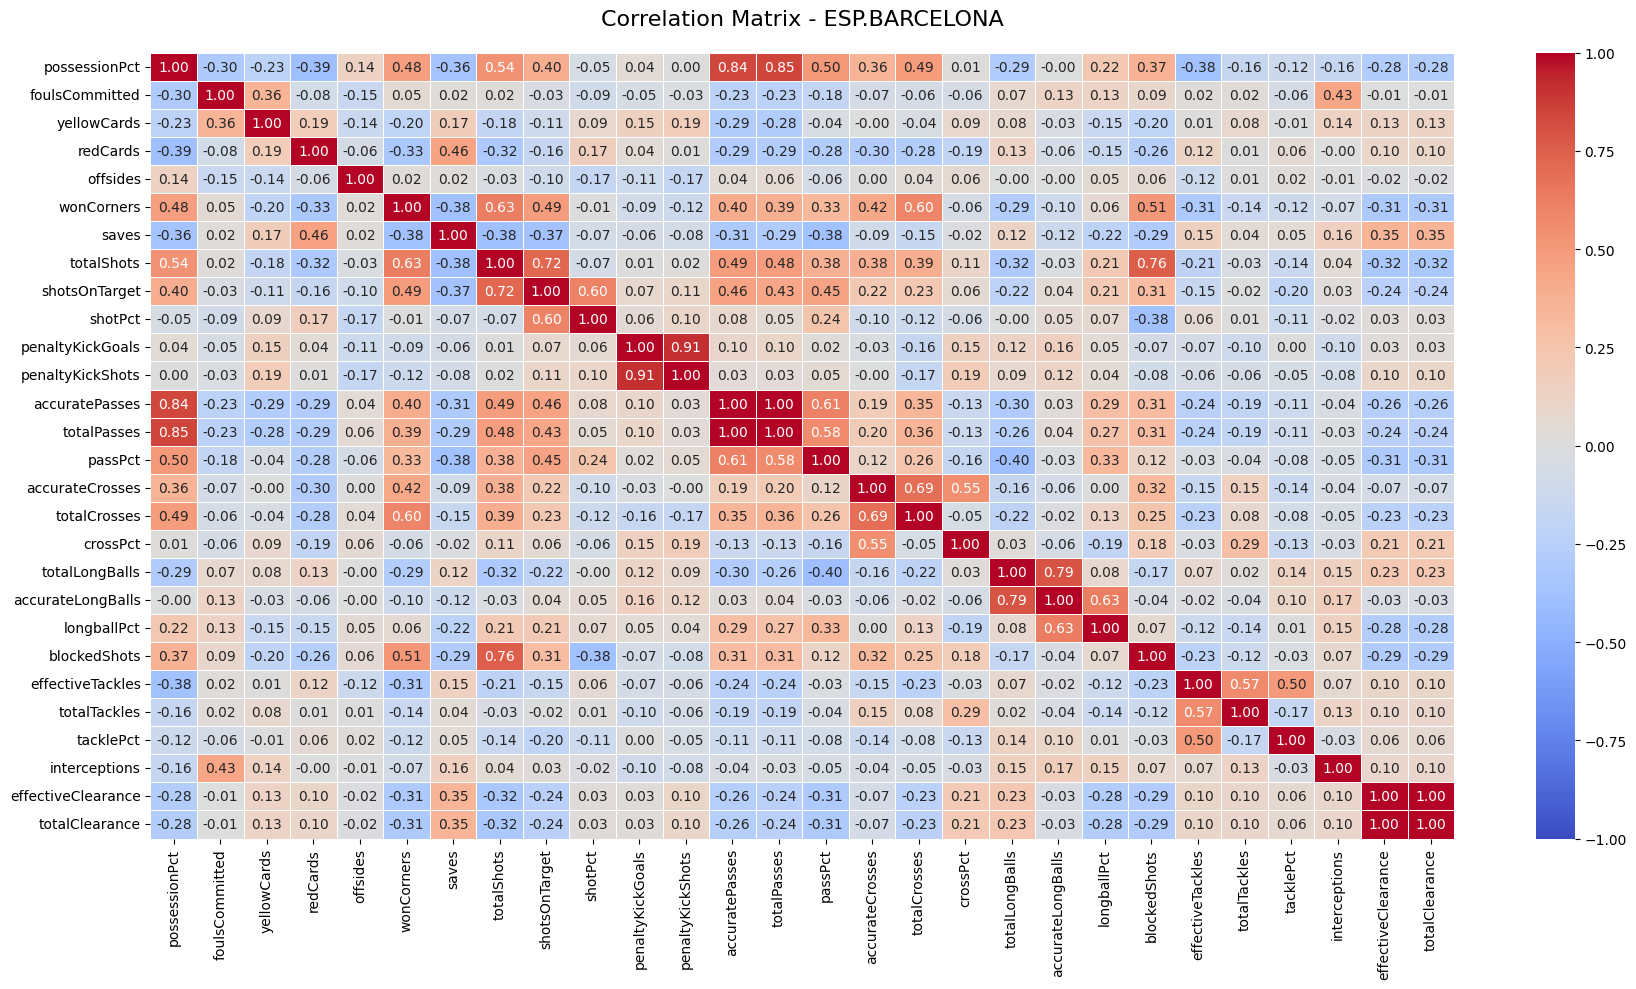

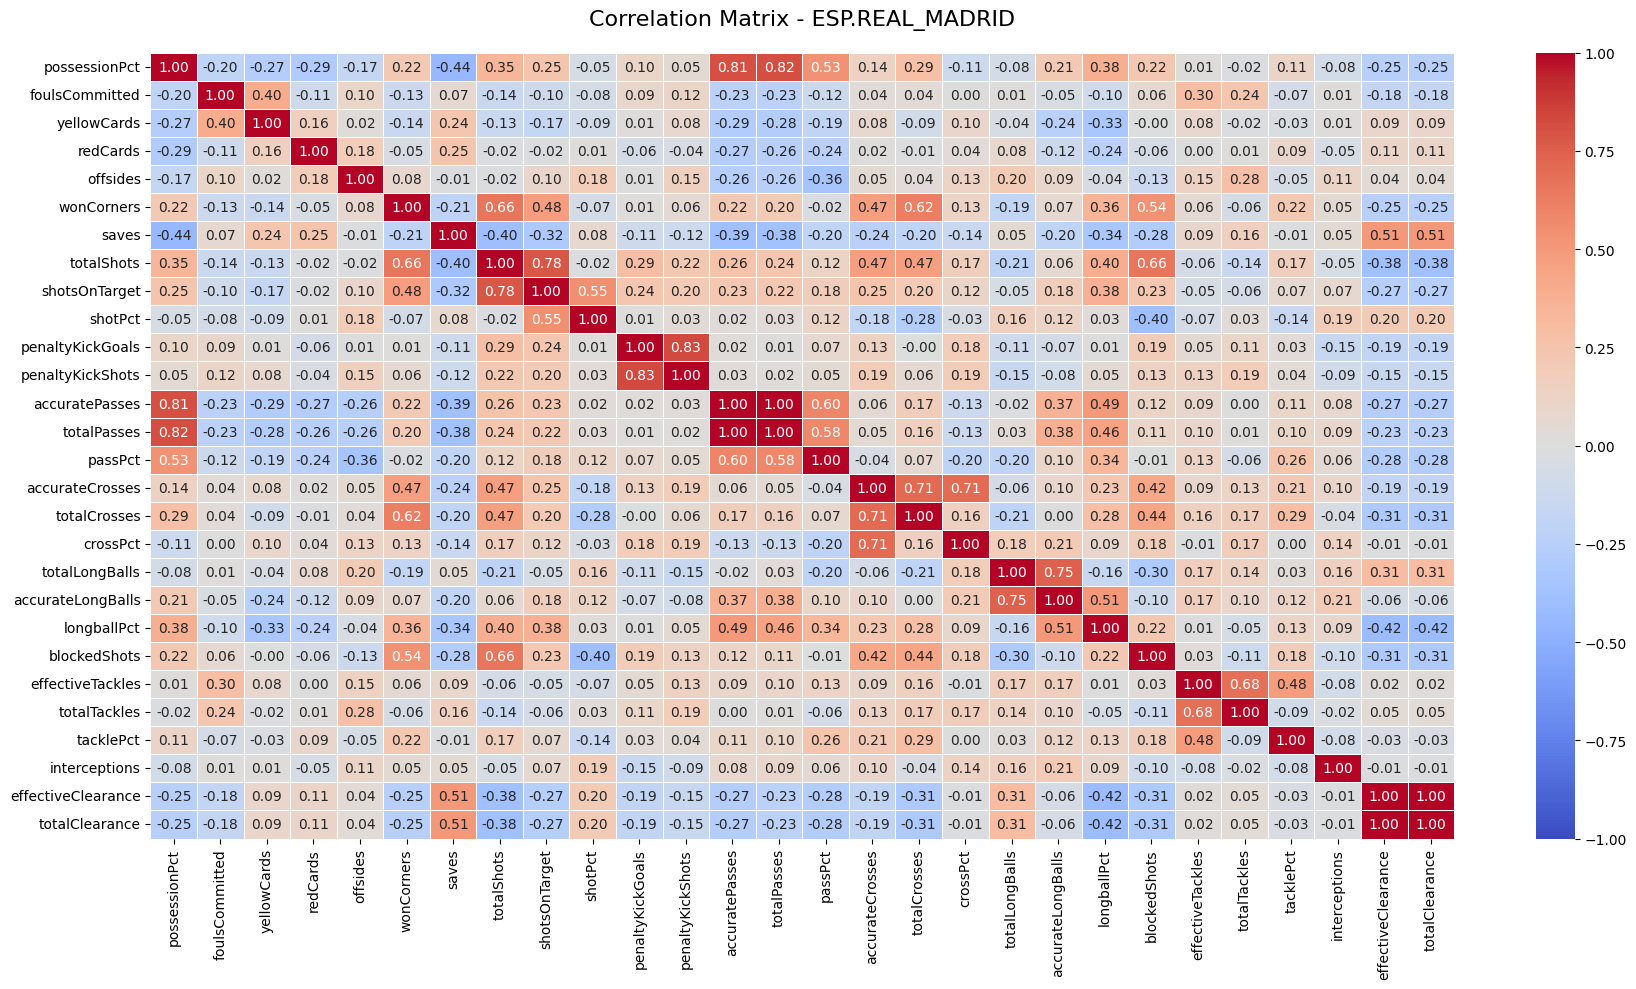

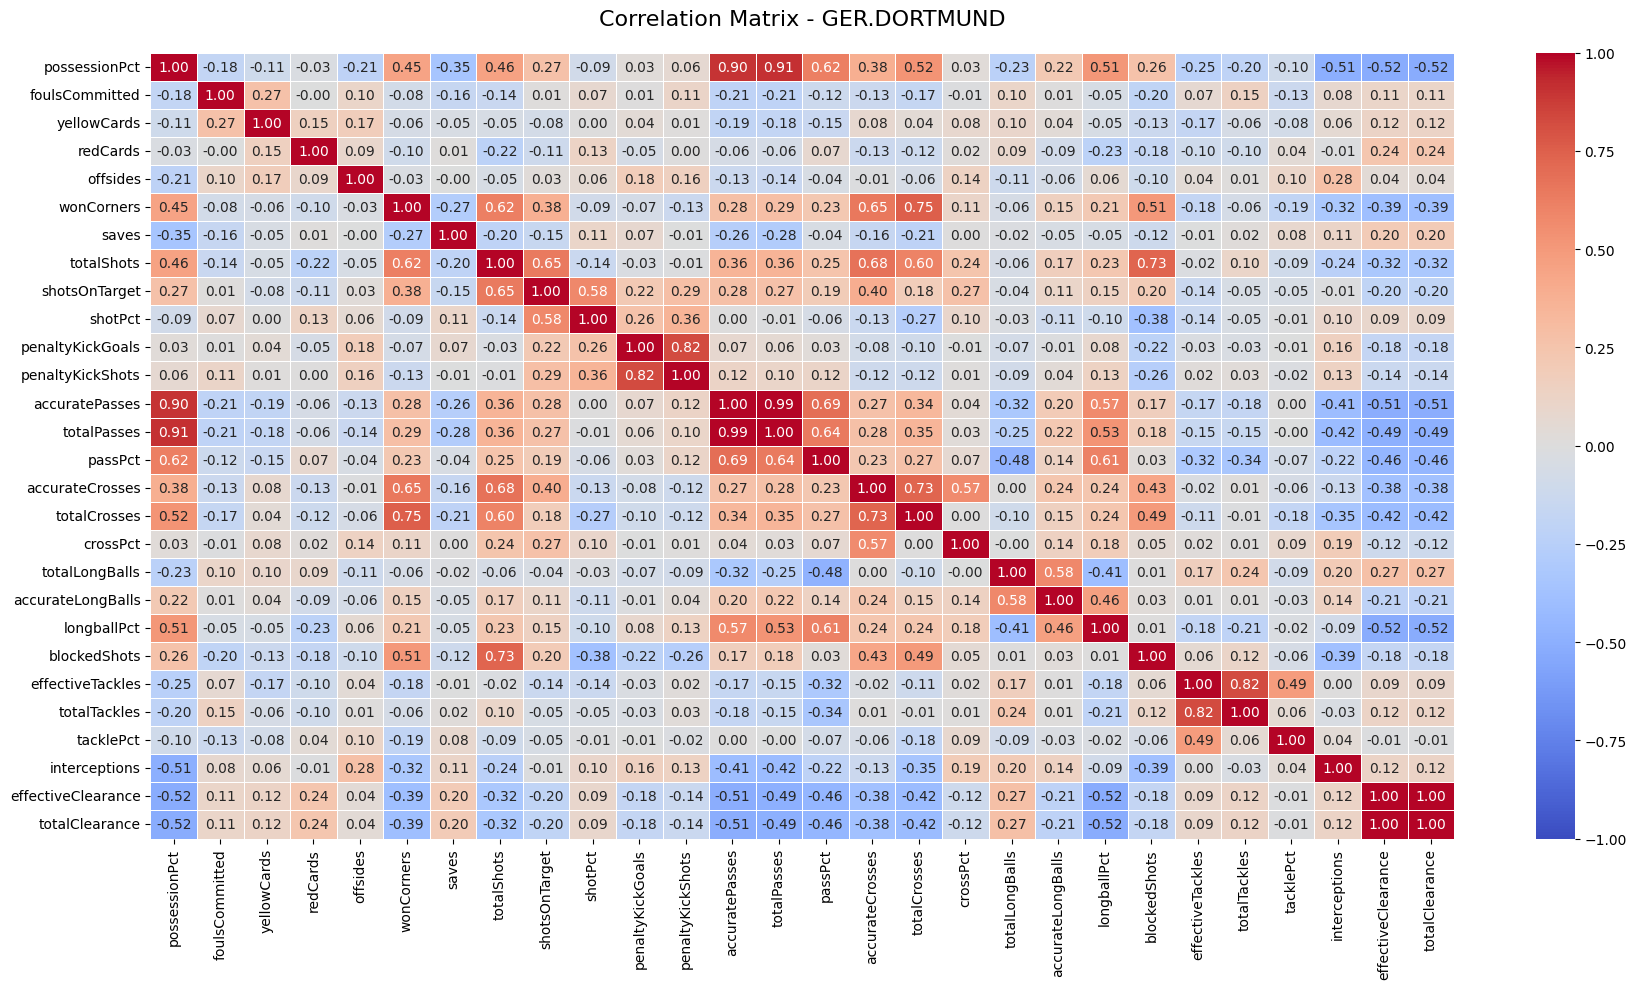

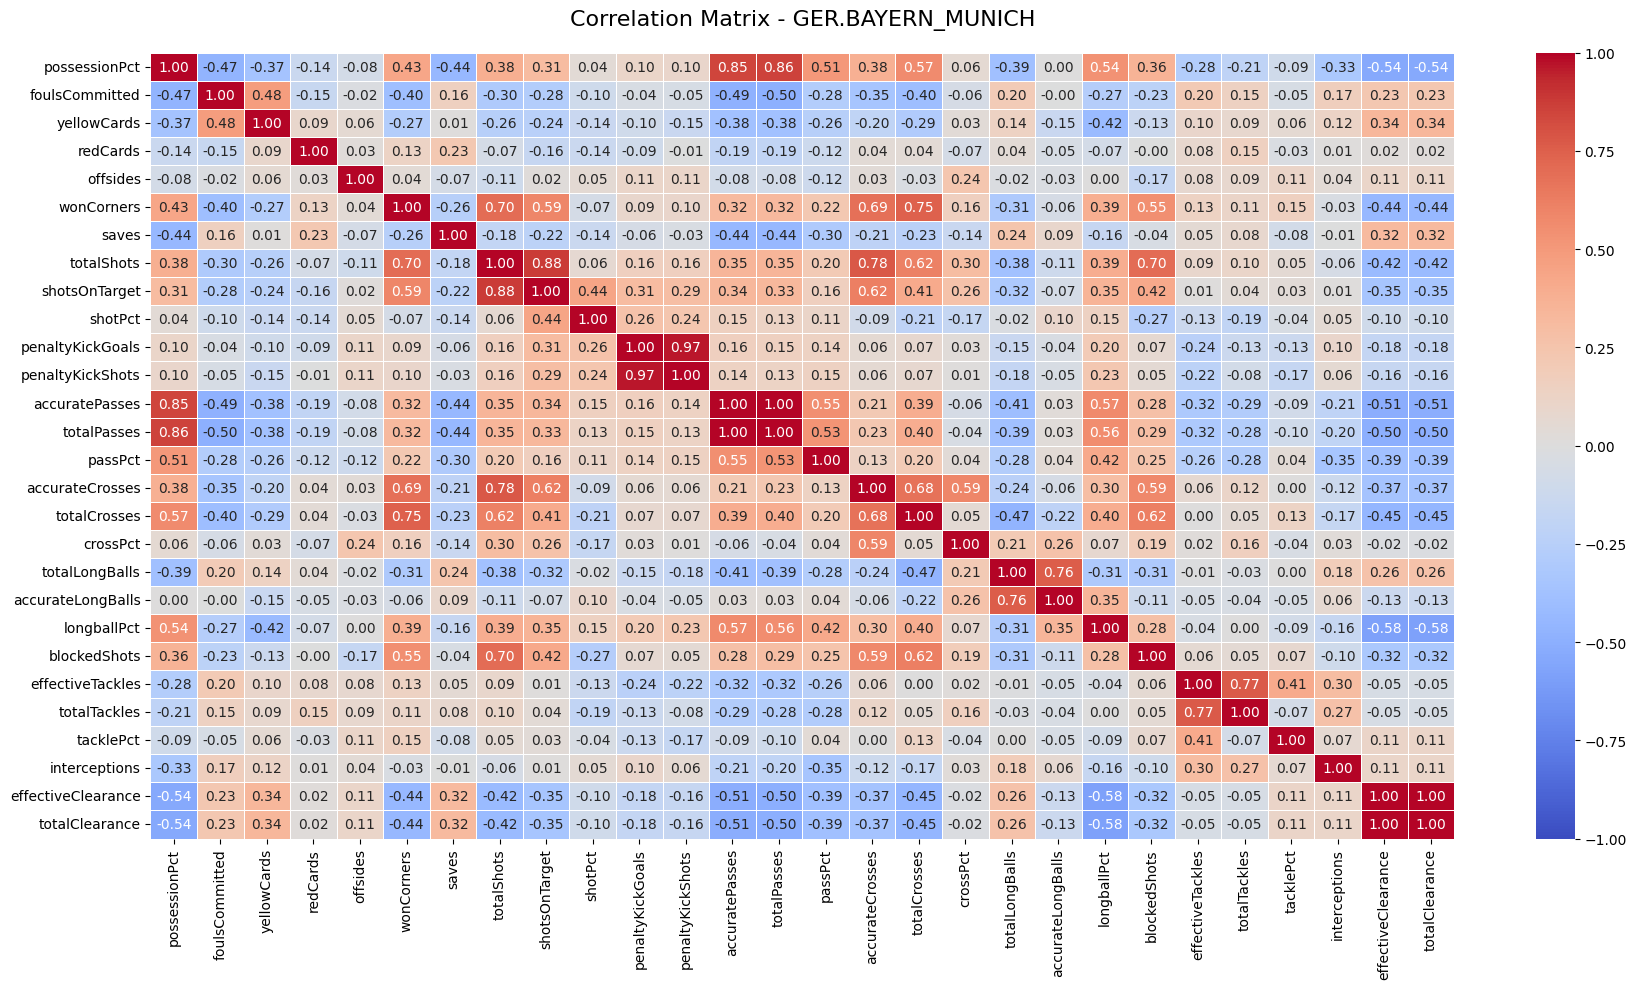

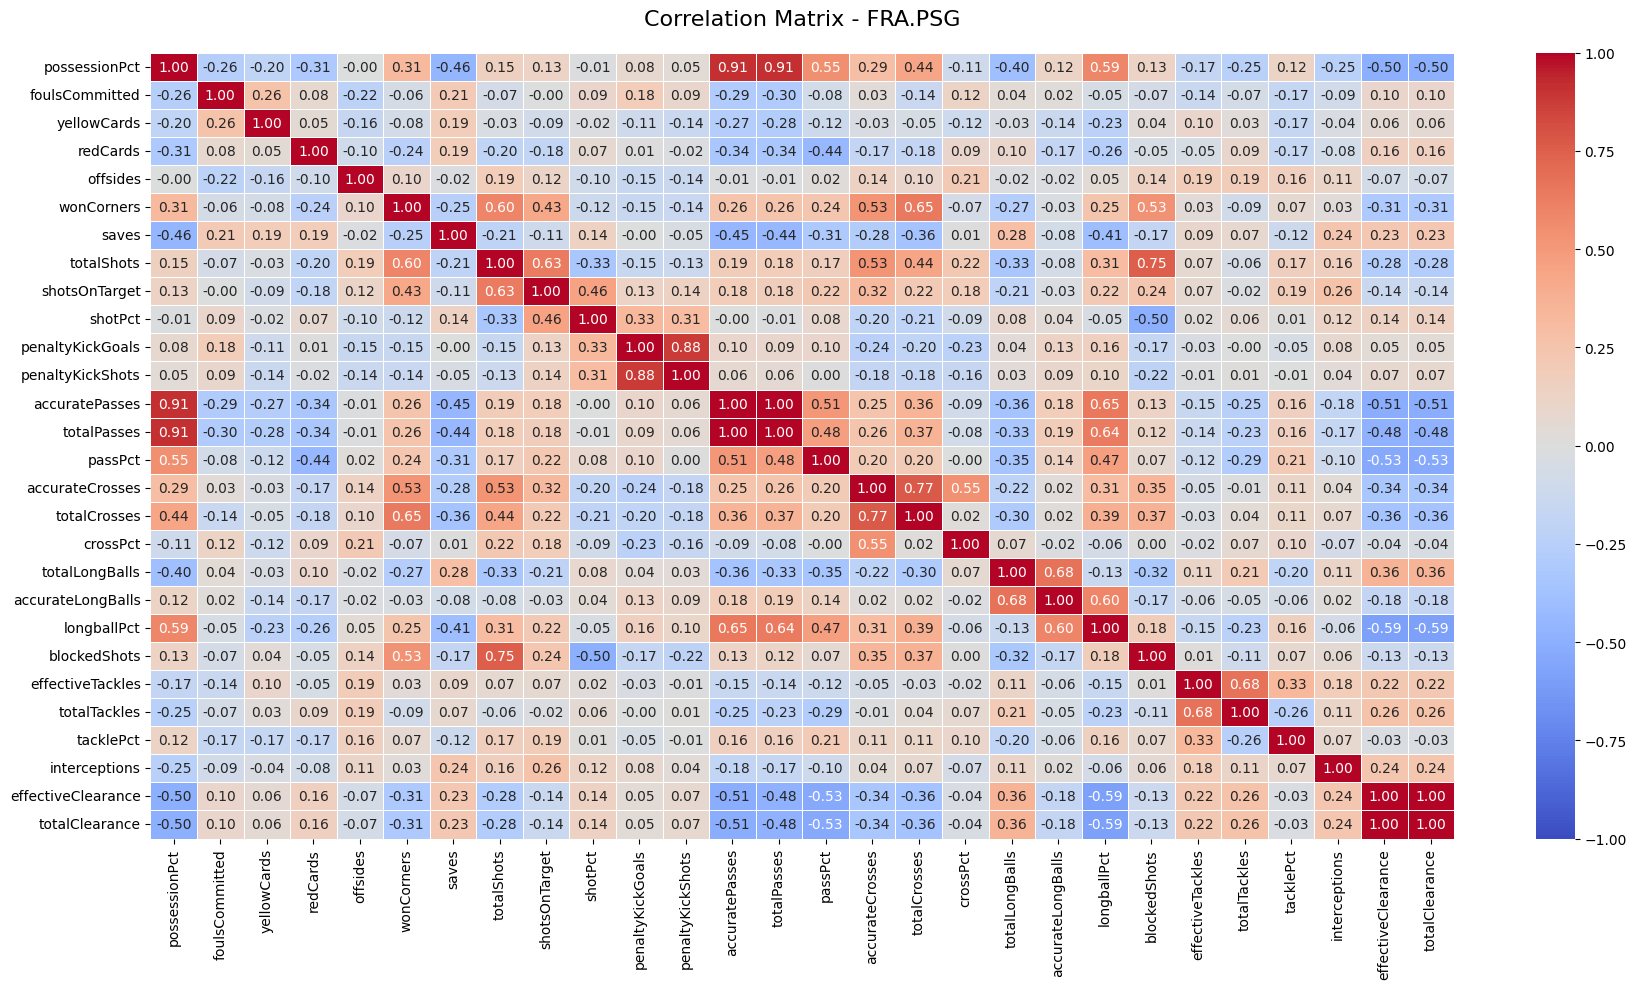

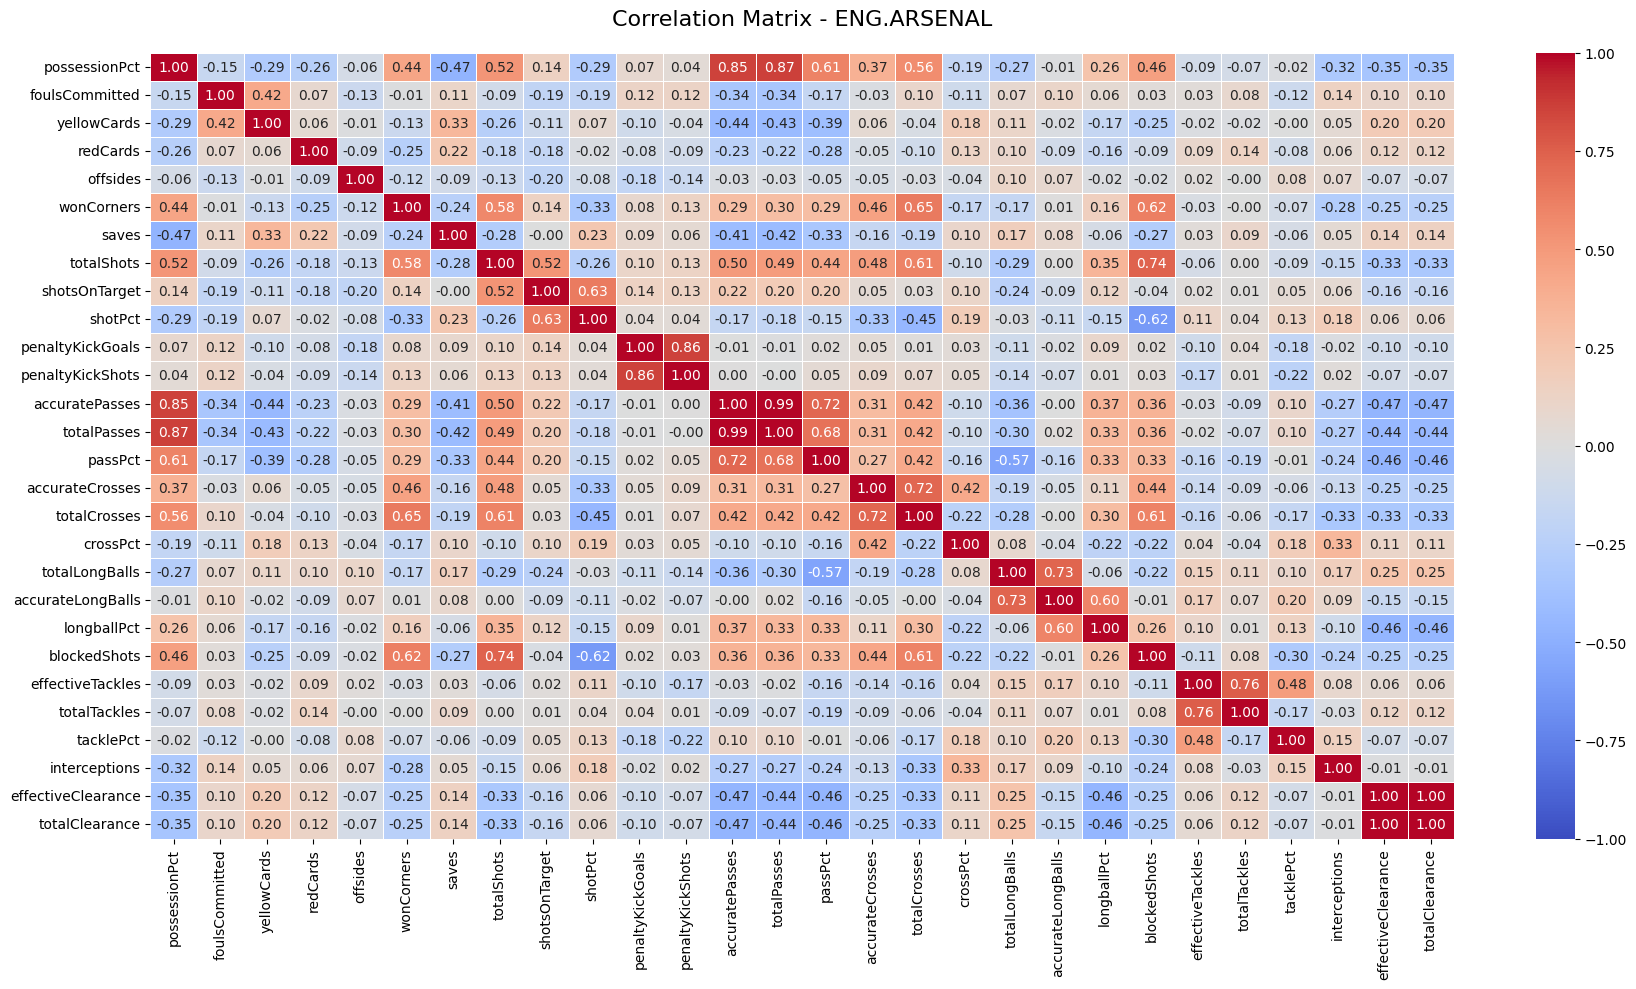

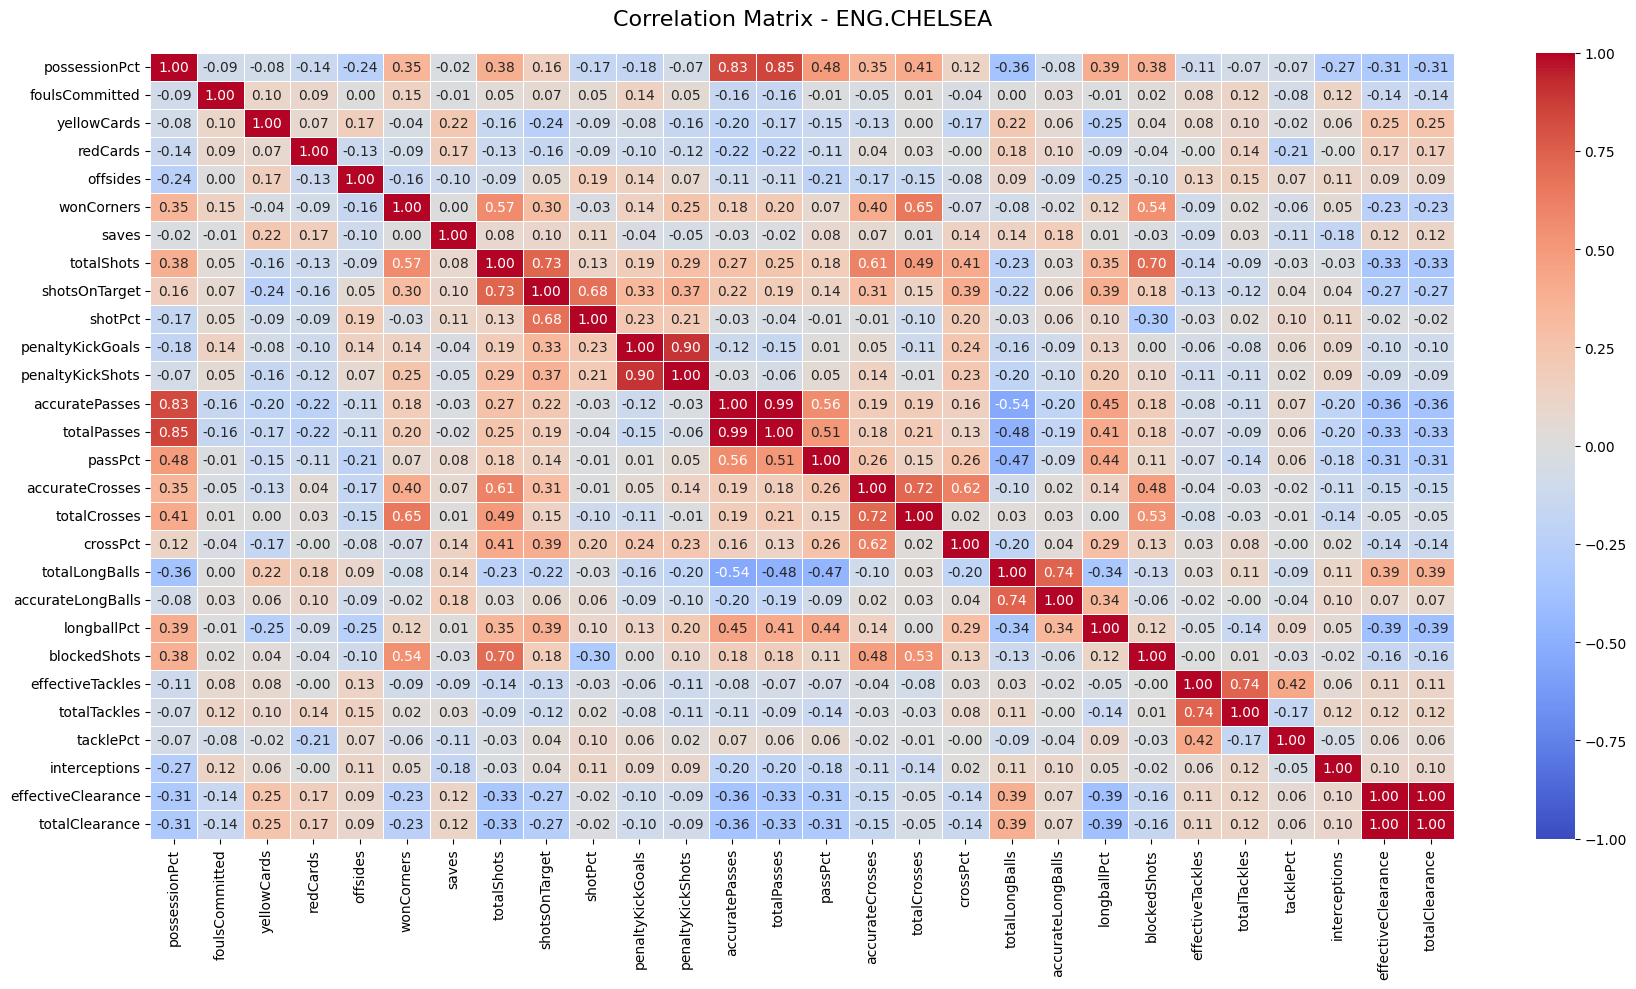

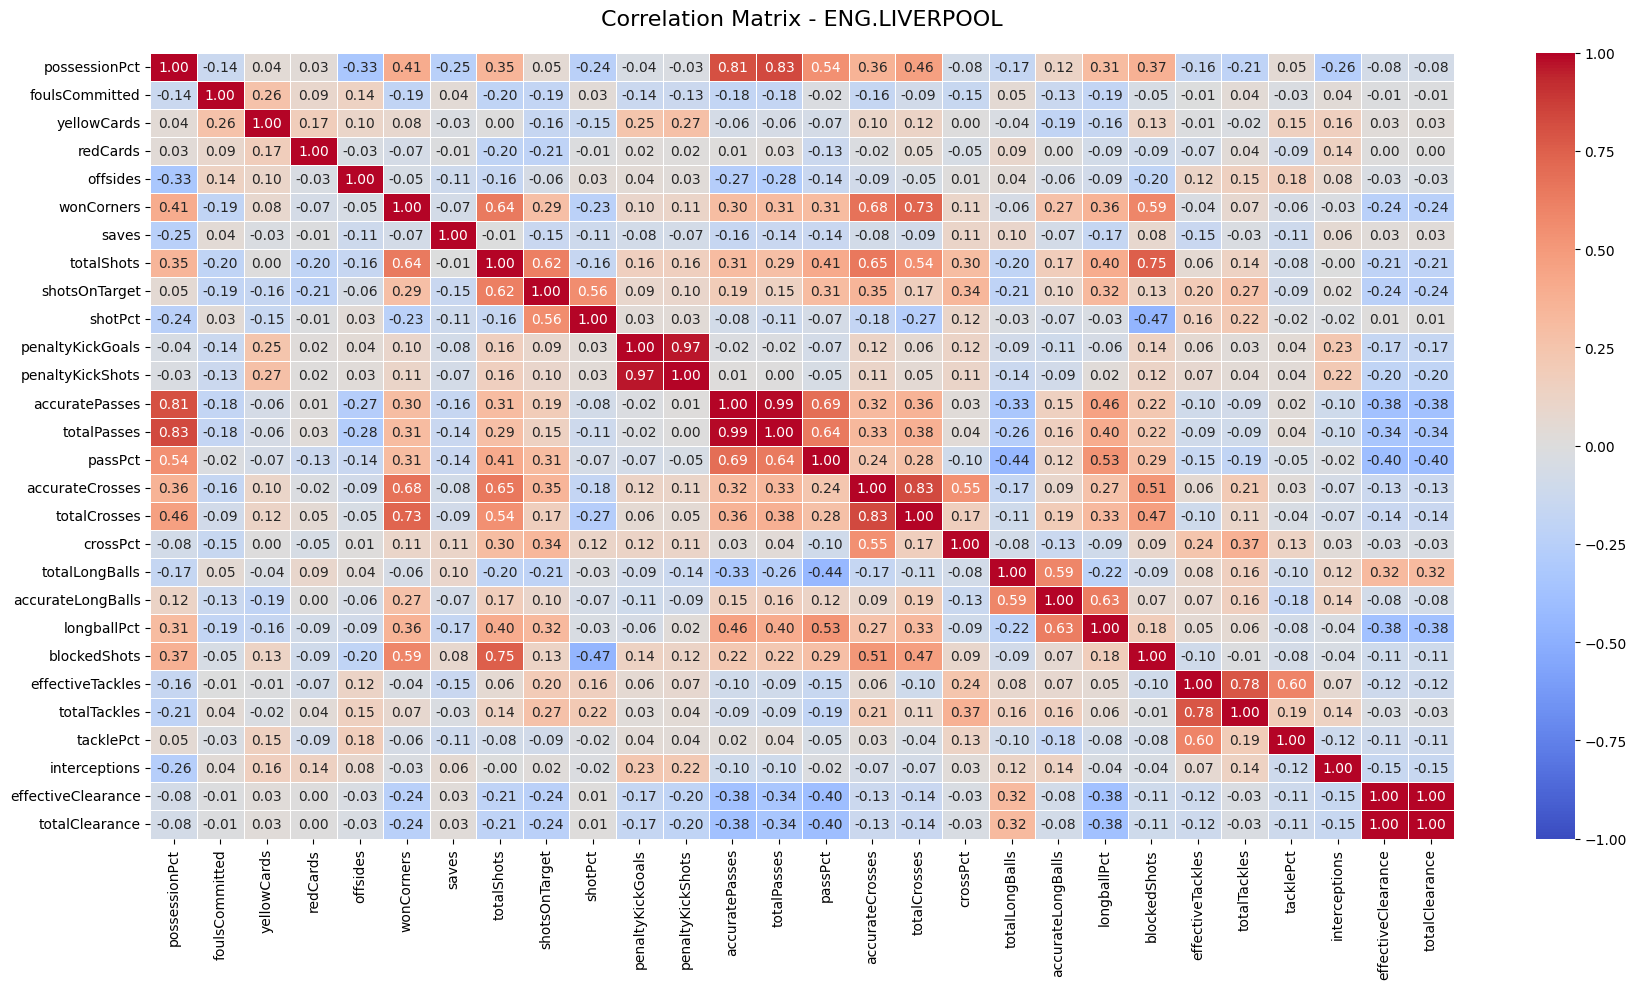

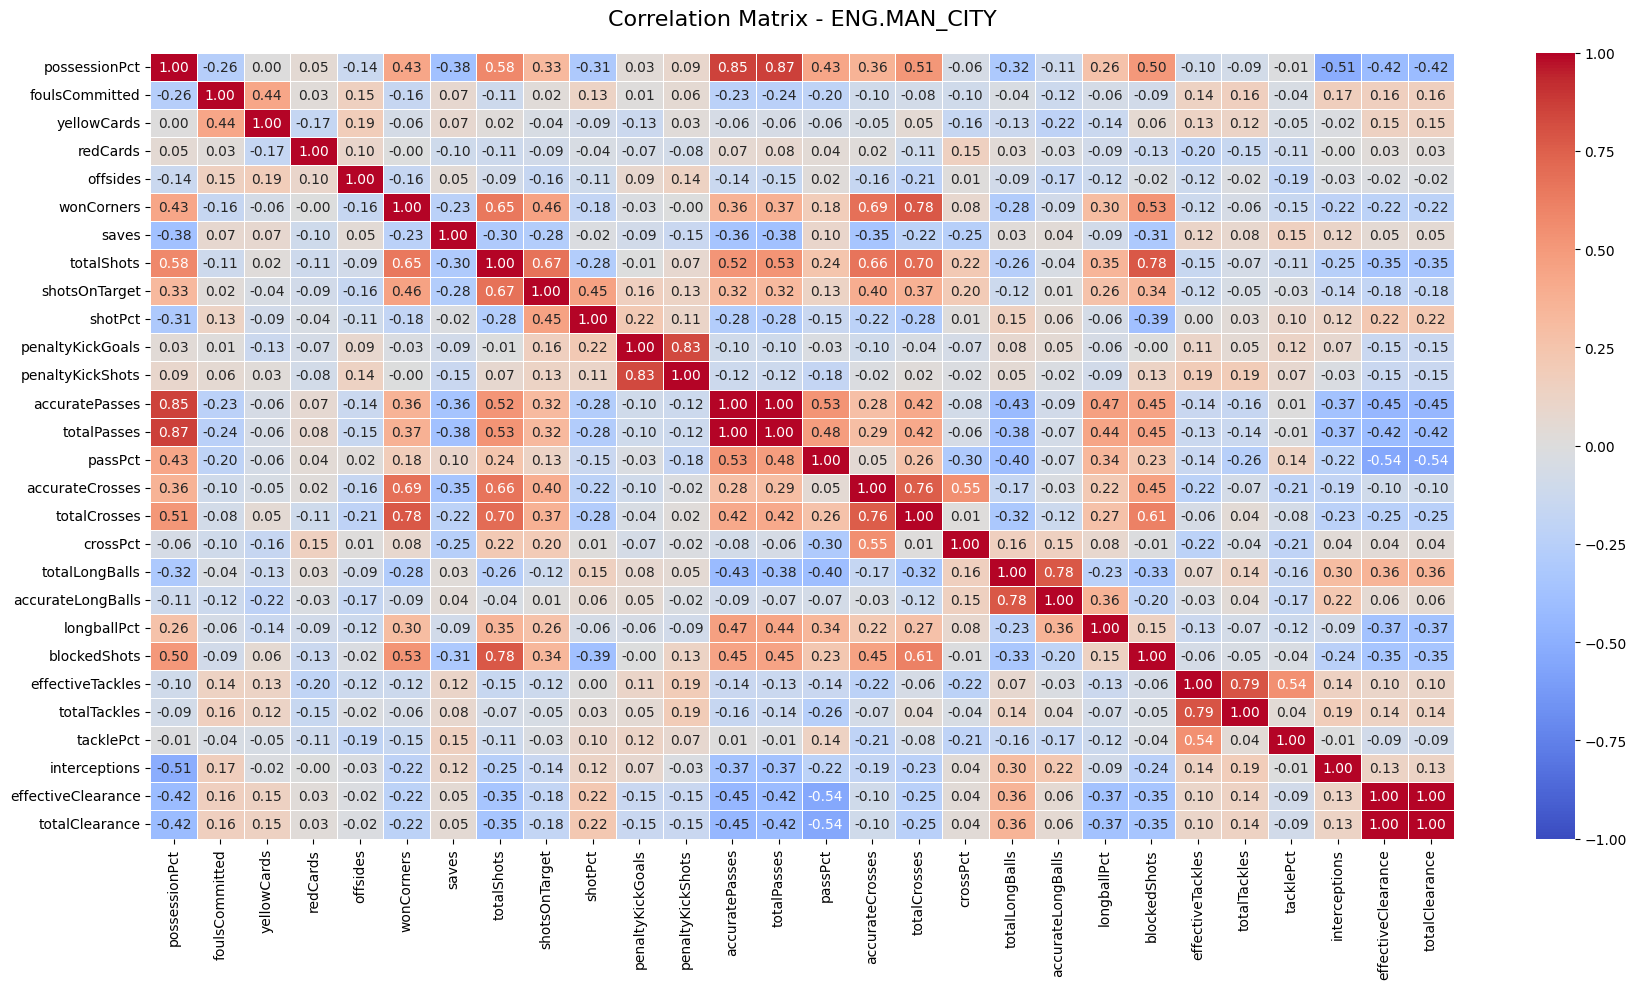

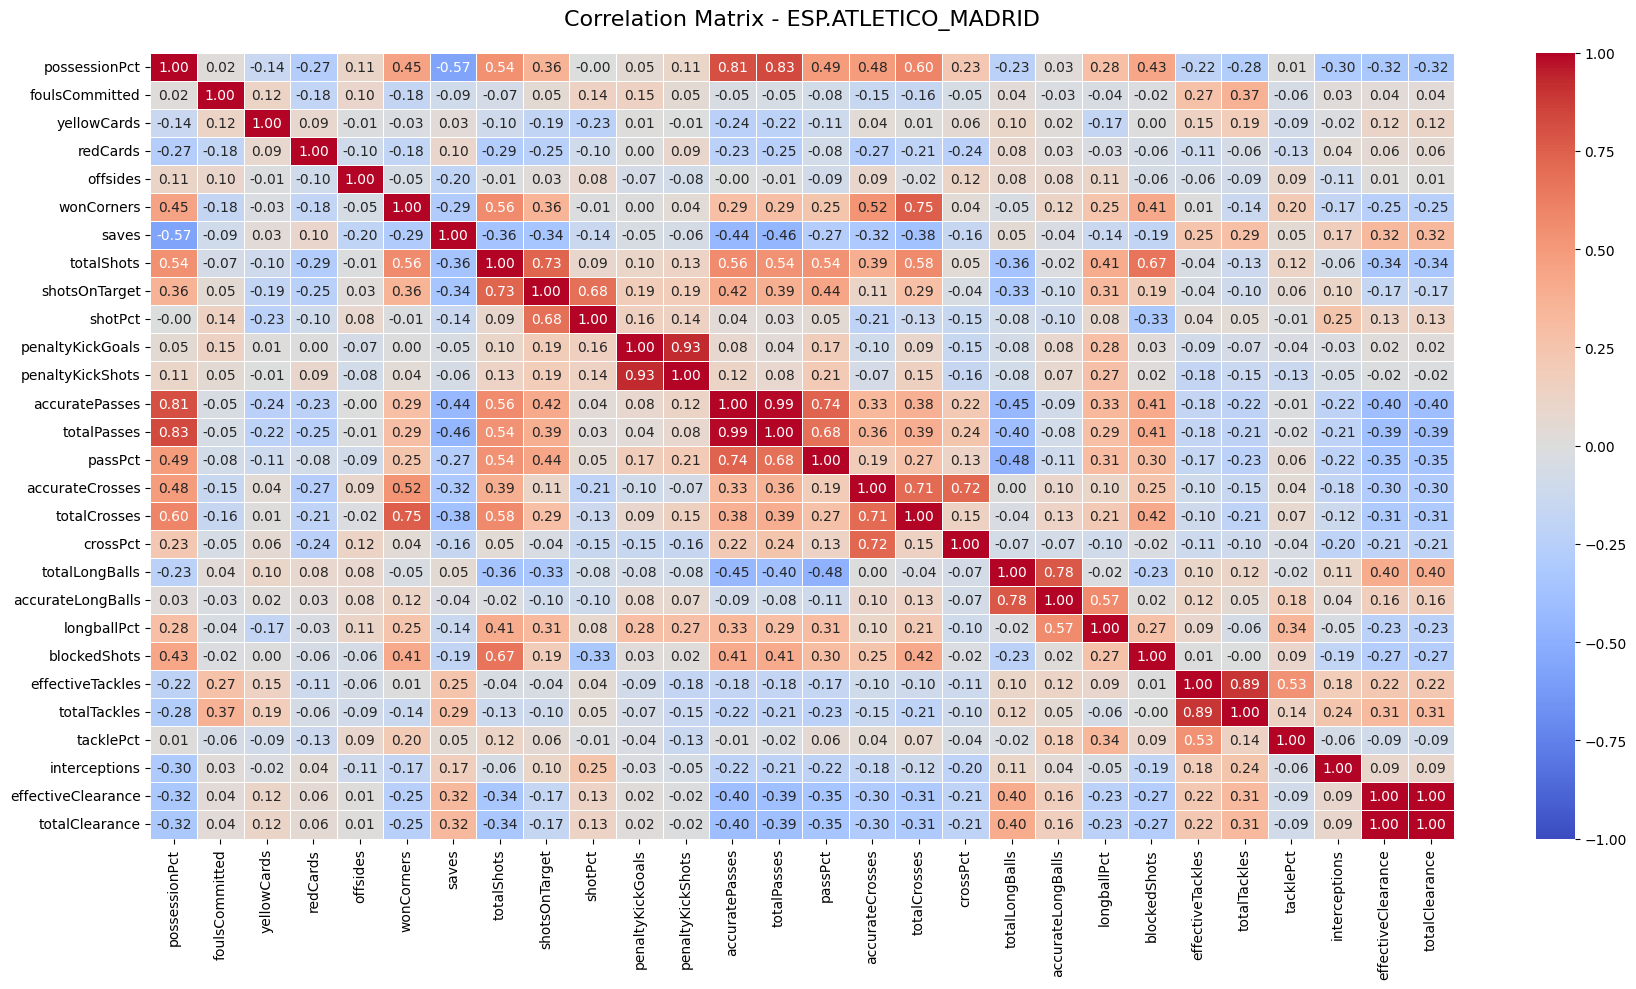

In [23]:
for team in teams:
    matriz_correlacion = equip_rep_clean.query(f"slug == '{team}'")[columns].corr()

    plt.figure(figsize=(18, 10))
    sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", 
                linewidths=.5, cbar=True, center=0, vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix - {team.upper()}", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

### INTERPRETACIÓN DE MATRICES DE CORRELACIÓN.

Con las matrices de Correlación, podemos constatar que existen variables con una clara dependencia de otras, por ejemplo tenemos el caso de "accurate passes" y "total passes" las cuales estan estrechamente relacionadas con la variable "possesion percentage".

##### Matriz de Correlación de los 10 equipos

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Por lo cual, esto claramente nos indica que en cada juego los equipos en todos sus pases son precisos y a su vez en cada uno de sus despejes son efectivos. Indicando así que su preparación antes del juego se basa en Pases y Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.89, 0.85 y 0.86) y son:

-PenaltyKickGoals(Goles de Penalty) con PenaltyKickShots(Tiros de Penalty), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼Los equipos por cada tiro de penalty tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalty.


##### Matriz de Correlación ESP.BARCELONA

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Por ende, esto claramente nos indica que en cada juego el equipo en todos sus pases son precisos y a su vez en cada uno de sus despejes son efectivos. Indicando así que su preparación antes del juego se basa en Pases y Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.91, 0.85 y 0.84) y son:

-PenaltyKickGoals(Goles de Penalty) con PenaltyKickShots(Tiros de Penalty), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalty.


##### Matriz de Correlación ESP.REAL_MADRID

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Indicando que en cada juego el equipo en todos sus pases son precisos y a su vez en cada uno de sus despejes son efectivos. Indicando así que su preparación antes del juego se basa en Pases y Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.83, 0.81 y 0.82) y son:

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalti.


##### Matriz de Correlación GER.DORTMUND

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Mostrando en cada juego que el equipo es uno de los mejores en despejes efectivos en todos sus despejes realizados. Teniendo así que su preparación antes del juego se basa en Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.90, 0.91, 0.82, 0.99 y 0.82) y son:

-EffectiveTackles(Entradas Efectivas) con TotalTackles(Entradas Totales), también viceversa

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

☼La mayoría de sus pases son de forma precisa.

☼Casi todas sus entradas(Tackles) son efectivas.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón, los tiros de penalti y las entradas(Tackles) efectivas.


##### Matriz de Correlación GER.BAYERN_MUNICH

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Indicando que en cada juego el equipo en todos sus pases son precisos y a su vez en cada uno de sus despejes son efectivos. Indicando así que su preparación antes del juego se basa en Pases y Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.85, 0.86, 0.88 y 0.97) y son:

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

-TotalShots(Tiros Totales) con ShotsOnTarget(Tiros a Puerta).

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

☼La mayoría de sus tiros realizados llegan a puerta.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón, los tiros de penalti y el enfoque de llevar el balón a puerta.


##### Matriz de Correlación FRA.PSG

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Indicando que en cada juego el equipo en todos sus pases son precisos y a su vez en cada uno de sus despejes son efectivos. Indicando así que su preparación antes del juego se basa en Pases y Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.91, 0.91 y 0.88) y son:

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalti.


##### Matriz de Correlación ENG.ARSENAL

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Mostrando en cada juego que el equipo es uno de los mejores en despejes efectivos en todos sus despejes realizados. Teniendo así que su preparación antes del juego se basa en Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.85, 0.87, 0.99 y 0.86) y son:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

☼La mayoría de sus pases son de forma precisa.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalti.


##### Matriz de Correlación ENG.CHELSEA

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Mostrando en cada juego que el equipo es uno de los mejores en despejes efectivos en todos sus despejes realizados. Teniendo así que su preparación antes del juego se basa en Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.99, 0.83, 0.85 y 0.90) y son:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

☼La mayoría de sus pases son de forma precisa.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalti.


##### Matriz de Correlación ENG.LIVERPOOL

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Mostrando en cada juego que el equipo es uno de los mejores en despejes efectivos en todos sus despejes realizados. Teniendo así que su preparación antes del juego se basa en Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.81, 0.83, 0.97, 0.83 y 0.99) y son:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

-AccurateCrosses(Centros Precisos) con TotalCrosses(Centros Totales), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

☼La mayoría de sus pases son de forma precisa.

☼Una gran parte de sus centros son precisos.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón, enfoque del centro y los tiros de penalti.


##### Matriz de Correlación ENG.MAN_CITY

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Por ende, esto claramente nos indica que en cada juego el equipo en todos sus pases son precisos y a su vez en cada uno de sus despejes son efectivos. Indicando así que su preparación antes del juego se basa en Pases y Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.83, 0.85 y 0.87) y son:

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón y los tiros de penalti.


##### Matriz de Correlación ESP.ATLETICO_MADRID

Entre nuestra matriz los 1.0 que no son correlación de una variable consigo misma están:

-TotalClearance(Despejes Totales) con EffectiveClearance(Despejes Efectivos), también viceversa.

Mostrando en cada juego que el equipo es uno de los mejores en despejes efectivos en todos sus despejes realizados. Teniendo así que su preparación antes del juego se basa en Despejes principalmente.

En segundo lugar, en la matriz se puede notar otras correlaciones destacables que tampoco son consigo mismas (0.81, 0.83, 0.97, 0.83 y 0.99) y son:

-TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa.

-PenaltyKickGoals(Goles de Penalti) con PenaltyKickShots(Tiros de Penalti), también viceversa.

-PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

-PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

-EffectiveTackles(Entradas Efectivas) con TotalTackles(Entradas Totales), también viceversa.

Lo anterior muestra una dinámica de que en cada juego:

☼El equipo por cada tiro de penalti tiene una posibilidad muy alta de ser un gol.

☼Mantienen un índice muy alto de poseer el balón durante todo el juego.

☼La mayoría de sus pases son de forma precisa.

☼Casi todas sus entradas(Tackles) son efectivas.

Teniendo que su segunda prioridad en el juego y las prácticas son los pases precisos, conservación del balón, los tiros de penalti y las entradas(Tackles) efectivas.
